<a href="https://colab.research.google.com/github/DheaCinb/indonesia-poverty-clustering-2023/blob/Linkstree/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT LIBRARY

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
import time

In [ ]:
!gdown '1X84DREbk1dUTyDYWxRHvueSktlvy5yg6' --output data.csv

Downloading...
From: https://drive.google.com/uc?id=1X84DREbk1dUTyDYWxRHvueSktlvy5yg6
To: /content/data.csv
100% 69.2k/69.2k [00:00<00:00, 73.0MB/s]


In [ ]:
# read csv data
dataset = pd.read_csv('data.csv')

In [ ]:
dataset.head()

,kabupaten,jumlah_penduduk_miskin,presentase_penduduk_miskin,p1,p2,garis_kemiskinan,tamat_kurang_sd,datam_sd_smp,tamat_lebih_dari_SMA,partisipasi_sekolah_7-12,...,bekerja_informal,bekerja_formal,tidak_bekerja.1,bekerja_pertanian,bekerja_bukan_pertanian,pengeluaran_makanan_miskin,pengeluaran_makanan_tidak_miskin,pengeluaran_makanan_total,air_layak,jamban
0,Simeulue,17.62,17.92,3.26,0.96,"538,693",13.39,55.61,31.00,98.21,...,34.97,9.61,55.42,33.99,10.59,63.76,56.63,57.18,71.50,69.37
1,Aceh Singkil,24.62,19.15,2.99,0.80,"568,691",16.4,53.55,30.04,100.00,...,31.29,22.04,46.66,35.54,17.8,69.28,60.10,61.00,73.55,84.30
2,Aceh Selatan,30.36,12.10,1.85,0.46,"494,565",18.38,52.27,29.34,95.72,...,23.07,16.45,60.49,21.15,18.36,62.02,61.57,61.59,80.26,74.33
3,Aceh Tenggara,27.96,12.45,1.59,0.33,"471,301",8.55,48.55,42.91,100.00,...,50.30,2.75,46.95,37.42,15.63,65.48,60.98,61.22,94.59,67.16
4,Aceh Timur,60.63,13.39,2.43,0.65,"530,934",4.38,66.54,29.08,100.00,...,17.10,27.03,55.87,27.89,16.24,64.65,60.39,60.66,71.82,82.72


# View Data That is Null

In [ ]:
dataset.isnull().sum()

,0
kabupaten,0
jumlah_penduduk_miskin,0
presentase_penduduk_miskin,0
p1,0
p2,0
garis_kemiskinan,0
tamat_kurang_sd,0
datam_sd_smp,0
tamat_lebih_dari_SMA,0
partisipasi_sekolah_7-12,0


# View Data Information

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   kabupaten                         514 non-null    object 
 1   jumlah_penduduk_miskin            514 non-null    float64
 2   presentase_penduduk_miskin        514 non-null    float64
 3   p1                                514 non-null    float64
 4   p2                                514 non-null    float64
 5   garis_kemiskinan                  514 non-null    object 
 6   tamat_kurang_sd                   514 non-null    object 
 7   datam_sd_smp                      514 non-null    float64
 8   tamat_lebih_dari_SMA              514 non-null    float64
 9   partisipasi_sekolah_7-12          514 non-null    float64
 10  partisipasi_sekolah_13-15         514 non-null    float64
 11  tidak_bekerja                     514 non-null    float64
 12  bekerja_

# Delete Data

In [ ]:
# Select the column to be deleted
columns_to_drop = ['garis_kemiskinan','tidak_bekerja.1',
                   'pengeluaran_makanan_total']
# Delete columns using the drop method and set axis=1
dataset = dataset.drop(columns_to_drop, axis=1)
# Viewing the results of deleted variables
dataset

,kabupaten,jumlah_penduduk_miskin,presentase_penduduk_miskin,p1,p2,tamat_kurang_sd,datam_sd_smp,tamat_lebih_dari_SMA,partisipasi_sekolah_7-12,partisipasi_sekolah_13-15,tidak_bekerja,bekerja_informal,bekerja_formal,bekerja_pertanian,bekerja_bukan_pertanian,pengeluaran_makanan_miskin,pengeluaran_makanan_tidak_miskin,air_layak,jamban
0,Simeulue,17.62,17.92,3.26,0.96,13.39,55.61,31.00,98.21,100.00,55.42,34.97,9.61,33.99,10.59,63.76,56.63,71.50,69.37
1,Aceh Singkil,24.62,19.15,2.99,0.80,16.4,53.55,30.04,100.00,100.00,46.66,31.29,22.04,35.54,17.8,69.28,60.10,73.55,84.30
2,Aceh Selatan,30.36,12.10,1.85,0.46,18.38,52.27,29.34,95.72,93.93,60.49,23.07,16.45,21.15,18.36,62.02,61.57,80.26,74.33
3,Aceh Tenggara,27.96,12.45,1.59,0.33,8.55,48.55,42.91,100.00,100.00,46.95,50.30,2.75,37.42,15.63,65.48,60.98,94.59,67.16
4,Aceh Timur,60.63,13.39,2.43,0.65,4.38,66.54,29.08,100.00,100.00,55.87,17.10,27.03,27.89,16.24,64.65,60.39,71.82,82.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,Puncak,42.01,36.44,9.12,3.34,76.52,21.04,2.44,53.91,24.11,6.79,91.07,2.14,91.07,2.14,75.92,73.17,40.84,21.69
510,Dogiyai,29.32,29.20,4.82,1.30,58.09,32.67,9.23,77.11,68.78,15.93,83.65,0.42,82.18,1.89,61.26,65.96,62.46,89.13
511,Intan Jaya,21.16,40.01,14.01,6.08,74.37,15.93,9.70,68.01,56.43,21.08,78.18,0.74,78.43,0.49,70.83,68.55,92.84,82.34
512,Deiyai,30.18,38.66,6.43,1.44,61.99,23.47,14.54,46.30,69.35,44.23,53.79,1.97,55.72,0.05,66.62,61.45,94.48,95.98


# Replace Data and Change Data Types


In [ ]:
# Counting the number of “-” values in the entire dataset
count_min = (dataset == '-').sum().sum()
count_min

np.int64(21)

In [ ]:
# Replace the character “-” with the value 'NaN'
dataset.replace('-', np.nan, inplace=True)

# Change the data type of objects to float from several columns
dataset[['tamat_kurang_sd','bekerja_formal', 'bekerja_pertanian',
         'bekerja_bukan_pertanian']] = dataset[['tamat_kurang_sd','bekerja_formal', 'bekerja_pertanian',
         'bekerja_bukan_pertanian']].astype(float)

# Print the DataFrame to see the changes
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   kabupaten                         514 non-null    object 
 1   jumlah_penduduk_miskin            514 non-null    float64
 2   presentase_penduduk_miskin        514 non-null    float64
 3   p1                                514 non-null    float64
 4   p2                                514 non-null    float64
 5   tamat_kurang_sd                   513 non-null    float64
 6   datam_sd_smp                      514 non-null    float64
 7   tamat_lebih_dari_SMA              514 non-null    float64
 8   partisipasi_sekolah_7-12          514 non-null    float64
 9   partisipasi_sekolah_13-15         514 non-null    float64
 10  tidak_bekerja                     514 non-null    float64
 11  bekerja_informal                  514 non-null    float64
 12  bekerja_

# Imputation Using The Average each Column


In [ ]:
# Imputation according to the average per column
for column in dataset.columns:
    if dataset[column].isnull().any():  # Checking whether there are null values in the column
        mean_value = dataset[column].mean() # Calculating the average of all columns
        dataset[column].fillna(mean_value, inplace=True) # Fill in the blank columns with averages
        print(f"\nKolom {column} diimputasi dengan rata-rata {mean_value:.2f}")


Kolom tamat_kurang_sd diimputasi dengan rata-rata 20.26

Kolom bekerja_formal diimputasi dengan rata-rata 17.18

Kolom bekerja_pertanian diimputasi dengan rata-rata 32.37

Kolom bekerja_bukan_pertanian diimputasi dengan rata-rata 26.26


/tmp/ipython-input-1447833450.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset[column].fillna(mean_value, inplace=True) # Fill in the blank columns with averages


In [ ]:
# Checking the result of imputation
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   kabupaten                         514 non-null    object 
 1   jumlah_penduduk_miskin            514 non-null    float64
 2   presentase_penduduk_miskin        514 non-null    float64
 3   p1                                514 non-null    float64
 4   p2                                514 non-null    float64
 5   tamat_kurang_sd                   514 non-null    float64
 6   datam_sd_smp                      514 non-null    float64
 7   tamat_lebih_dari_SMA              514 non-null    float64
 8   partisipasi_sekolah_7-12          514 non-null    float64
 9   partisipasi_sekolah_13-15         514 non-null    float64
 10  tidak_bekerja                     514 non-null    float64
 11  bekerja_informal                  514 non-null    float64
 12  bekerja_

# View Data Statistic

In [ ]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
jumlah_penduduk_miskin,514.0,50.386926,55.766151,1.47,14.9175,28.075000,67.3550,453.76
presentase_penduduk_miskin,514.0,11.499903,7.154441,2.27,6.5700,9.615000,14.1075,40.01
p1,514.0,1.938743,1.856757,0.11,0.8400,1.440000,2.2300,14.01
p2,514.0,0.529337,0.739919,0.01,0.1700,0.310000,0.5700,6.94
tamat_kurang_sd,514.0,20.262144,11.747438,1.04,11.9175,18.245000,26.6275,76.52
datam_sd_smp,514.0,53.257023,10.046876,15.93,47.1400,53.485000,59.8650,79.95
tamat_lebih_dari_SMA,514.0,26.520019,11.298325,2.44,17.8175,25.240000,33.6000,65.57
partisipasi_sekolah_7-12,514.0,97.768794,6.222580,46.30,98.2150,100.000000,100.0000,100.00
partisipasi_sekolah_13-15,514.0,91.891907,11.781516,24.11,87.5275,97.030000,100.0000,100.00
tidak_bekerja,514.0,42.558774,9.925840,0.74,36.6625,43.145000,49.2775,69.01


# Viewing the Number of Outliers in Each Column


In [ ]:
# Function to calculate outliers based on the IQR method
def calculate_outlier(dataset):
    outliers = {}  # Dictionary to store the number of outliers each columns
    for column in dataset.select_dtypes(include=['float64', 'int64']).columns:  # Cek hanya column numerik
        # Calculating Q1 and Q3
        Q1 = dataset[column].quantile(0.25)
        Q3 = dataset[column].quantile(0.75)
        # Calculating IQR
        IQR = Q3 - Q1
        # Determining the lower and upper limits for outliers
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR

        # Calculating the outlier
        outlier = dataset[(dataset[column] < lower_limit) | (dataset[column] > upper_limit)].shape[0]

        # Save to dictionary
        outliers[column] = outlier

    return outliers

# Create object to store the outlier calculations
outlier_count = calculate_outlier(dataset)

# Display the number of outliers per column in vertical format
print("Number of Outliers per Column:")
for column, number_of_outlier in outlier_count.items():
    print(f"{column}: {number_of_outlier}")


Number of Outliers per Column:
jumlah_penduduk_miskin: 35
presentase_penduduk_miskin: 34
p1: 44
p2: 49
tamat_kurang_sd: 13
datam_sd_smp: 9
tamat_lebih_dari_SMA: 6
partisipasi_sekolah_7-12: 61
partisipasi_sekolah_13-15: 28
tidak_bekerja: 14
bekerja_informal: 9
bekerja_formal: 2
bekerja_pertanian: 12
bekerja_bukan_pertanian: 2
pengeluaran_makanan_miskin: 14
pengeluaran_makanan_tidak_miskin: 15
air_layak: 22
jamban: 18


# Performing Scaling using Robust


In [ ]:
# Selecting Numeric Column
X = dataset.iloc[:,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]].values
X

array([[17.62, 17.92,  3.26, ..., 56.63, 71.5 , 69.37],
       [24.62, 19.15,  2.99, ..., 60.1 , 73.55, 84.3 ],
       [30.36, 12.1 ,  1.85, ..., 61.57, 80.26, 74.33],
       ...,
       [21.16, 40.01, 14.01, ..., 68.55, 92.84, 82.34],
       [30.18, 38.66,  6.43, ..., 61.45, 94.48, 95.98],
       [32.79, 10.5 ,  2.12, ..., 41.78, 90.6 , 88.58]])

In [ ]:
from sklearn.preprocessing import RobustScaler

# Create RobustScaler Object
scaler = RobustScaler()

# Implementation Robust Scaler to Data
data_scaled = scaler.fit_transform(X)

pd_data = pd.DataFrame(data_scaled)
pd_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-0.199380,1.101824,1.309353,1.625,-0.330048,0.166994,0.364961,-1.002801,0.238124,0.973048,-0.168786,-0.457030,0.070205,-0.692777,0.344444,0.572402,-0.774367,-1.010013
1,-0.065888,1.265008,1.115108,1.225,-0.125425,0.005108,0.304134,0.000000,0.238124,0.278637,-0.343754,0.436893,0.137370,-0.326043,1.220635,1.045315,-0.686053,-0.243389
2,0.043576,0.329685,0.294964,0.375,0.009177,-0.095481,0.259781,-2.397759,-0.248547,1.374950,-0.734577,0.034880,-0.486181,-0.297558,0.068254,1.245656,-0.396984,-0.755327
3,-0.002193,0.376119,0.107914,0.050,-0.659075,-0.387819,1.119594,0.000000,0.238124,0.301625,0.560086,-0.950378,0.218835,-0.436419,0.617460,1.165247,0.220355,-1.123492
4,0.620834,0.500829,0.712230,0.850,-0.942556,1.025933,0.243307,0.000000,0.238124,1.008720,-1.018424,0.795757,-0.194121,-0.405392,0.485714,1.084838,-0.760582,-0.324519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,0.265745,3.558872,5.525180,7.575,3.961591,-2.549705,-1.444638,-25.820728,-5.846462,-2.881887,2.498514,-0.994247,2.543610,-1.122584,2.274603,2.826576,-2.095207,-3.458280
510,0.023743,2.598342,2.431655,2.475,2.708702,-1.635756,-1.014415,-12.823529,-2.264983,-2.157352,2.145727,-1.117943,2.158386,-1.135300,-0.052381,1.843952,-1.163813,0.004621
511,-0.131871,4.032504,9.043165,14.425,3.815432,-2.951277,-0.984635,-17.921569,-3.255161,-1.749108,1.885653,-1.094930,1.995890,-1.206511,1.466667,2.196934,0.144965,-0.344031
512,0.040143,3.853400,3.589928,2.825,2.973827,-2.358743,-0.677966,-30.084034,-2.219282,0.086009,0.726019,-1.006472,1.011815,-1.228891,0.798413,1.229302,0.215617,0.356354


# Corellation Analys

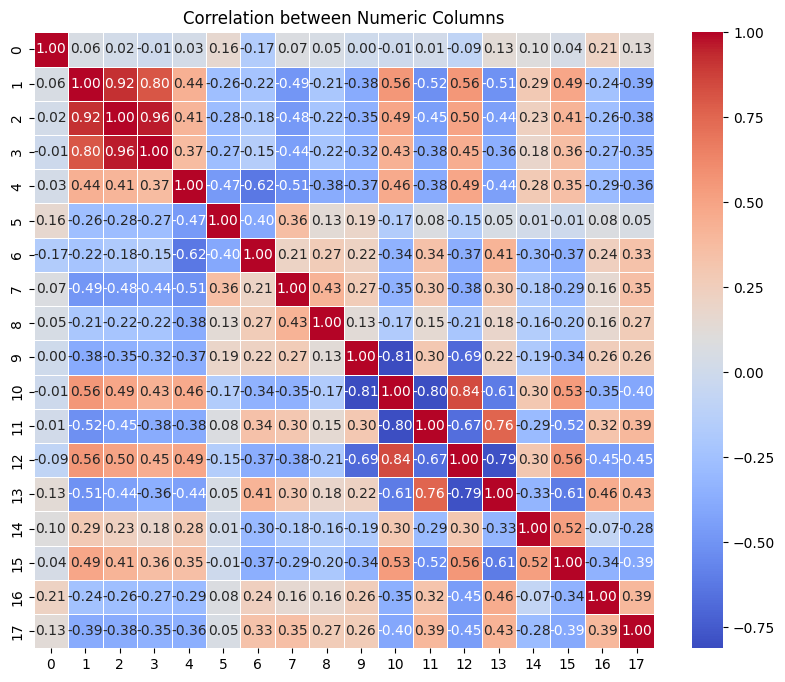

In [ ]:
# Calculate the correlation between numeric columns
corelattion = pd_data.corr()

# print(corelattion)
# Create a heatmap from correlation metrics
plt.figure(figsize=(10, 8))
sns.heatmap(corelattion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation between Numeric Columns')
plt.show()

There appears to be a high correlation between several variables.

# PCA Process

Cumulative explained variance for 3 components: 0.8265


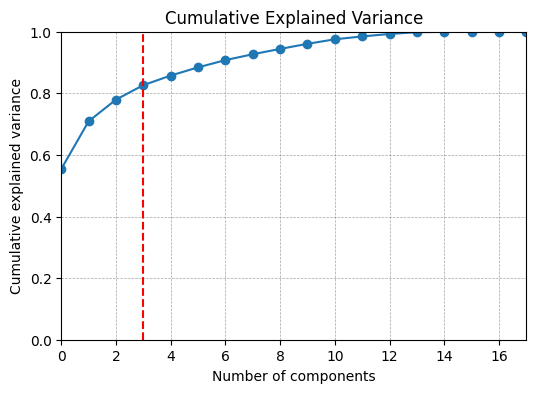

In [ ]:
pca = PCA().fit(pd_data)

# Take the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Hitung varians kumulatif
cumulative_variance = np.cumsum(explained_variance_ratio)

# Calculate the cumulative variance
three_component_variance = cumulative_variance[3]  #
print(f'Cumulative explained variance for 3 components: {three_component_variance:.4f}')

# Visualization
plt.figure(figsize=(6, 4))
plt.plot(cumulative_variance, marker='o')
plt.axvline(x=3, color='r', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.xlim(0, len(cumulative_variance)-1)
plt.ylim(0, 1)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

In [ ]:
# Create 3 PCA Components
pca = PCA(n_components=3)

# Fit PCA on standardised data and data transformation
X_pca = pca.fit_transform(pd_data)

# Take the components and variance ratios described
data_pca = pca.components_

# Creating a DataFrame for 3 components
components_df = pd.DataFrame(data = data_pca, columns=[f'Feature {i+1}' for i in range(data_scaled.shape[1])])
components_df.index = [f'PC {i+1}' for i in range(data_pca.shape[0])]

# View result table
print(" PCA Components:")
print(components_df)

 PCA Components:
      Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  Feature 6  \
PC 1   0.017863  -0.167275  -0.239064  -0.314357  -0.121319   0.077191   
PC 2   0.038831   0.263280   0.424388   0.589556   0.041545   0.010463   
PC 3   0.040123   0.040996   0.224839   0.406959  -0.187083  -0.120399   

      Feature 7  Feature 8  Feature 9  Feature 10  Feature 11  Feature 12  \
PC 1   0.050750   0.846179   0.107496    0.076027   -0.097825    0.079106   
PC 2  -0.049040   0.504151   0.042397   -0.108749    0.150639   -0.128888   
PC 3   0.272883  -0.061115   0.104798    0.210802   -0.291082    0.246362   

      Feature 13  Feature 14  Feature 15  Feature 16  Feature 17  Feature 18  
PC 1   -0.107139    0.080720   -0.056932   -0.092729    0.056397    0.101384  
PC 2    0.152062   -0.128140    0.082703    0.144989   -0.116010   -0.096408  
PC 3   -0.311173    0.284787   -0.254150   -0.312174    0.237912    0.235418  


In [ ]:
# Create a new DataFrame with the PCA results
pca_df = pd.DataFrame(data=X_pca , columns=['PCA1', 'PCA2','PCA3'])

# View PCA result
pca_df

,PCA1,PCA2,PCA3
0,-0.541426,1.631035,0.213172
1,0.460395,1.830319,-0.038424
2,-0.855202,-0.758805,0.094231
3,1.067232,0.698512,-0.939763
4,1.194284,0.937345,0.384838
...,...,...,...
509,-27.836898,-2.741172,-1.086964
510,-12.963176,-1.632001,-1.808152
511,-23.208380,5.965640,4.692103
512,-27.675657,-10.163288,1.466124


# Merge Initial Dataset (district column) with PCA Results Data

In [ ]:
# Select the desired column
selected_data1 = dataset[['kabupaten']]
selected_data2 = pca_df[['PCA1', 'PCA2','PCA3']]

# Vertically combine
combined_data = pd.concat([selected_data1, selected_data2], axis=1, ignore_index=True)

# Changing column names after merging
combined_data.columns = ['kabupaten', 'PCA1', 'PCA2','PCA3']

# View the result
print("Vertical Combined Data : ")
print(combined_data)

Vertical Combined Data : 
         kabupaten       PCA1       PCA2      PCA3
0         Simeulue  -0.541426   1.631035  0.213172
1     Aceh Singkil   0.460395   1.830319 -0.038424
2     Aceh Selatan  -0.855202  -0.758805  0.094231
3    Aceh Tenggara   1.067232   0.698512 -0.939763
4       Aceh Timur   1.194284   0.937345  0.384838
..             ...        ...        ...       ...
509         Puncak -27.836898  -2.741172 -1.086964
510        Dogiyai -12.963176  -1.632001 -1.808152
511     Intan Jaya -23.208380   5.965640  4.692103
512         Deiyai -27.675657 -10.163288  1.466124
513  Kota Jayapura  -1.402541  -1.874007  2.990290

[514 rows x 4 columns]


In [ ]:
from google.colab import files
# Simpan DataFrame ke file CSV
file_name = 'hasil_preprocessing.csv'
combined_data.to_csv(file_name, index=False)

# Unduh file ke komputer lokal
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Clustering K-Means

In [ ]:
# Memilih kolom-kolom numeric
data_select = combined_data.iloc[:,[1,2,3]].values
data_select

array([[ -0.54142554,   1.63103534,   0.2131724 ],
       [  0.46039493,   1.8303188 ,  -0.03842427],
       [ -0.8552023 ,  -0.75880488,   0.09423054],
       ...,
       [-23.20838024,   5.96563992,   4.69210279],
       [-27.67565731, -10.16328804,   1.46612426],
       [ -1.40254101,  -1.87400704,   2.9902898 ]])

k=2: Silhouette Score=0.7973, Running Time=0.0552 seconds
k=3: Silhouette Score=0.5661, Running Time=0.1245 seconds
k=4: Silhouette Score=0.3201, Running Time=0.1208 seconds
k=5: Silhouette Score=0.3641, Running Time=0.1334 seconds
k=6: Silhouette Score=0.3774, Running Time=0.1371 seconds
k=7: Silhouette Score=0.3623, Running Time=0.1446 seconds
k=8: Silhouette Score=0.3609, Running Time=0.1632 seconds
k=9: Silhouette Score=0.3134, Running Time=0.1714 seconds
k=10: Silhouette Score=0.3118, Running Time=0.1832 seconds

Hasil terbaik:
k terbaik = 2 dengan Silhouette Score = 0.7973

Visualisasi clustering untuk k=2:


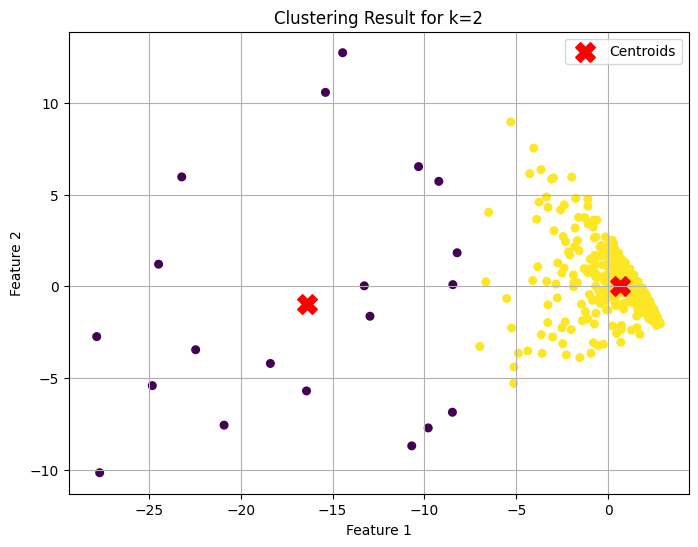

In [ ]:
# Inisialisasi daftar untuk menyimpan nilai silhouette coefficient dan running time
silhouette_scores = []
execution_times = []

# Inisialisasi range untuk jumlah cluster (k)
k_values = range(2, 11)

# Lakukan clustering untuk k = 2 hingga k = 10
for k in k_values:
    # Start timer
    start_time = time.time()

    # Inisialisasi dan pelatihan KMeans
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',  # Inisialisasi centroid
        n_init=50,         # Jumlah inisialisasi
        max_iter=500,      # Iterasi maksimum
        tol=1e-4,          # Toleransi konvergensi
        random_state=42    # Untuk hasil konsisten
    )

    # Melatih model dan mendapatkan label
    labels = kmeans.fit_predict(data_select)

    # Hitung Silhouette Coefficient
    silhouette_avg = silhouette_score(data_select, labels)
    silhouette_scores.append(silhouette_avg)

    # End timer
    end_time = time.time()
    execution_time = end_time - start_time
    execution_times.append(execution_time)

    # Print hasil untuk setiap k
    print(f"k={k}: Silhouette Score={silhouette_avg:.4f}, Running Time={execution_time:.4f} seconds")

# Menentukan k terbaik
best_k = k_values[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("\nHasil terbaik:")
print(f"k terbaik = {best_k} dengan Silhouette Score = {best_score:.4f}")

# Visualisasi hasil clustering untuk k terbaik
print(f"\nVisualisasi clustering untuk k={best_k}:")
kmeans_best = KMeans(
    n_clusters=best_k,
    init='k-means++',
    n_init=50,
    max_iter=500,
    tol=1e-4,
    random_state=42
)
best_labels = kmeans_best.fit_predict(data_select)

# Scatter plot hasil clustering
plt.figure(figsize=(8, 6))
plt.scatter(data_select[:, 0], data_select[:, 1], c=best_labels, cmap='viridis', s=30)
plt.scatter(kmeans_best.cluster_centers_[:, 0], kmeans_best.cluster_centers_[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.title(f'Clustering Result for k={best_k}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.legend()
plt.show()


# Melihat karakteristik tiap cluster

# Langkah 1 : Menggabungkan data setelah preprocessing dengan label

In [ ]:
clustered_data = dataset

# Tambahkan kolom label klaster
clustered_data['Cluster'] = best_labels

clustered_data

,Kabupaten,Jumlah Penduduk Miskin,Persentase Penduduk Miskin,Tingkat Kedalaman Kemiskinan (P1),Indeks Keparahan Kemiskinan(P2),< SD,Tamat SD/SMP,>SMA,Angka Partisipasi Sekolah (7-12),Angka Partisipasi Sekolah (7-12).1,Tidak Bekerja,Bekerja di Sektor Informal,Bekerja di Sektor Formal,Bekerja di Sektor Pertanian,Bekerja Bukan di Sektor Pertanian,Pengeluaran Perkapita untuk makanan(Miskin),Pengeluaran Perkapita untuk makanan(Tidak Miskin),Air Layak,Jamban Sendiri/Bersama,Cluster
0,Simeulue,17.62,17.92,3.26,0.96,13.39,55.61,31.00,98.21,100.00,55.42,34.97,9.61,33.99,10.59,63.76,56.63,71.50,69.37,1
1,Aceh Singkil,24.62,19.15,2.99,0.80,16.40,53.55,30.04,100.00,100.00,46.66,31.29,22.04,35.54,17.80,69.28,60.10,73.55,84.30,1
2,Aceh Selatan,30.36,12.10,1.85,0.46,18.38,52.27,29.34,95.72,93.93,60.49,23.07,16.45,21.15,18.36,62.02,61.57,80.26,74.33,1
3,Aceh Tenggara,27.96,12.45,1.59,0.33,8.55,48.55,42.91,100.00,100.00,46.95,50.30,2.75,37.42,15.63,65.48,60.98,94.59,67.16,1
4,Aceh Timur,60.63,13.39,2.43,0.65,4.38,66.54,29.08,100.00,100.00,55.87,17.10,27.03,27.89,16.24,64.65,60.39,71.82,82.72,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,Puncak,42.01,36.44,9.12,3.34,76.52,21.04,2.44,53.91,24.11,6.79,91.07,2.14,91.07,2.14,75.92,73.17,40.84,21.69,0
510,Dogiyai,29.32,29.20,4.82,1.30,58.09,32.67,9.23,77.11,68.78,15.93,83.65,0.42,82.18,1.89,61.26,65.96,62.46,89.13,0
511,Intan Jaya,21.16,40.01,14.01,6.08,74.37,15.93,9.70,68.01,56.43,21.08,78.18,0.74,78.43,0.49,70.83,68.55,92.84,82.34,0
512,Deiyai,30.18,38.66,6.43,1.44,61.99,23.47,14.54,46.30,69.35,44.23,53.79,1.97,55.72,0.05,66.62,61.45,94.48,95.98,0


# Langkah 2: Analisis Setiap Klaster

In [ ]:
# Filter data untuk Cluster 1, 2, dan 3
cluster_1 = clustered_data[clustered_data['Cluster'] == 0]
cluster_2 = clustered_data[clustered_data['Cluster'] == 1]

# Menampilkan jumlah anggota di masing-masing cluster
print(f"Jumlah anggota di Cluster 1: {len(cluster_1)}")
print(f"Jumlah anggota di Cluster 2: {len(cluster_2)}")


Jumlah anggota di Cluster 1: 20
Jumlah anggota di Cluster 2: 494


In [ ]:
# Filter data untuk Cluster 1
cluster_1 = clustered_data[clustered_data['Cluster'] == 0]
print(f"Data dalam Cluster 1:\n{cluster_1}\n")

# Filter data untuk Cluster 2
cluster_2 = clustered_data[clustered_data['Cluster'] == 1]
print(f"Data dalam Cluster 2:\n{cluster_2}\n")

Data dalam Cluster 1:
                   Kabupaten  Jumlah Penduduk Miskin  \
70          Kota Sawah Lunto                   1.470   
380  Bolaang Mongondow Timur                   4.320   
466          Halmahera Utara                   9.180   
483         Pegunungan Arfak                  11.714   
486               Jayawijaya                  73.420   
491                   Paniai                  61.140   
492              Puncak Jaya                  47.500   
494             Boven Digoel                  14.250   
496                    Asmat                  25.580   
497                 Yahukimo                  72.140   
498       Pegunungan Bintang                  23.320   
499                 Tolikara                  48.400   
505                    Nduga                  43.270   
506               Lanny Jaya                  76.430   
507         Mamberamo Tengah                  19.830   
508                   Yalimo                  21.670   
509                   Punc

# Melihat Distribusi Presentase Penduduk Miskin per Cluster

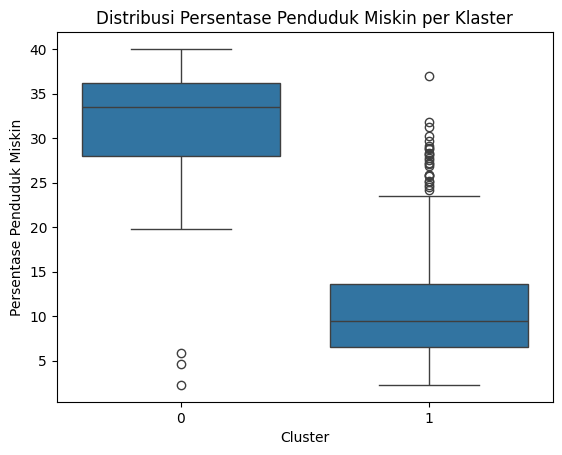

In [ ]:
import seaborn as sns

# Boxplot untuk persentase penduduk miskin antar klaster
sns.boxplot(x='Cluster', y='Persentase Penduduk Miskin', data=clustered_data)
plt.title('Distribusi Persentase Penduduk Miskin per Klaster')
plt.show()


Dari visualisasi distribusi presentase penduduk miskin per klaster terlihat bahwa :
1. Cluster 0 merupakan cluster dengan tingkat kemiskinan rendah
2. Cluster 1 merupakan cluster dengan tingkat kemiskinan tinggi
3. CLuster 2 merupakan cluster dengan tingkat kemiskinan menengah

# Langkah 3: Ringkas Data Berdasarkan Statistik

In [ ]:
# Statistik deskriptif untuk Cluster 1
print("Statistik Deskriptif untuk Cluster 1:")
print(cluster_1.describe(include='all'))
print("\n")

# Statistik deskriptif untuk Cluster 2
print("Statistik Deskriptif untuk Cluster 2:")
print(cluster_2.describe(include='all'))
print("\n")


Statistik Deskriptif untuk Cluster 1:
               Kabupaten  Jumlah Penduduk Miskin  Persentase Penduduk Miskin  \
count                 20               20.000000                   20.000000   
unique                20                     NaN                         NaN   
top     Kota Sawah Lunto                     NaN                         NaN   
freq                   1                     NaN                         NaN   
mean                 NaN               33.815200                   28.850500   
std                  NaN               23.244129                   11.656338   
min                  NaN                1.470000                    2.270000   
25%                  NaN               18.435000                   27.990000   
50%                  NaN               27.450000                   33.500000   
75%                  NaN               47.725000                   36.170000   
max                  NaN               76.430000                   40.010000   

 

# Nilai Rata-Rata per indikator di setiap cluster

In [ ]:
# Pilih hanya kolom numerik untuk operasi rata-rata
numerical_columns = clustered_data.select_dtypes(include=['float64', 'int64']).columns

# Lakukan groupby hanya pada kolom numerik
mean_per_cluster = clustered_data.groupby('Cluster')[numerical_columns].mean()

# Tampilkan hasil
print("Rata-rata indikator per klaster:")
print(mean_per_cluster)


Rata-rata indikator per klaster:
         Jumlah Penduduk Miskin  Persentase Penduduk Miskin  \
Cluster                                                       
0                     33.815200                   28.850500   
1                     51.057846                   10.797449   

         Tingkat Kedalaman Kemiskinan (P1)  Indeks Keparahan Kemiskinan(P2)  \
Cluster                                                                       
0                                 6.635350                         2.424950   
1                                 1.748597                         0.452591   

             < SD  Tamat SD/SMP       >SMA  Angka Partisipasi Sekolah (7-12)  \
Cluster                                                                        
0        49.71650     35.387000  14.896000                         72.170000   
1        19.06966     53.980506  26.990628                         98.805182   

         Angka Partisipasi Sekolah (7-12).1  Tidak Bekerja  \
Cluster       

# Download Hasil Data Gabungan

In [ ]:
# # Simpan DataFrame ke dalam file CSV
# combined_data_clustering.to_csv('data_bersih.xlsx', index=False)

# from google.colab import files
# files.download('data_bersih.xlsx')